In [1]:
import numpy as np
import matplotlib.pyplot as plt

import cnetwork
from cnetwork import MagmaChamber, GlobalSystemThreshold

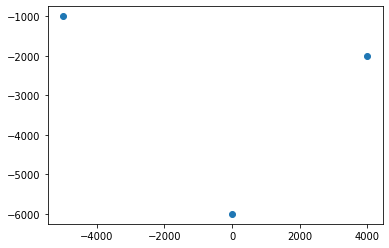

In [2]:
# Set reference density of melt
rhoref = 2500
# Set limits of characteristic size of chamber
R_ref = 1000
# Uniformly randomly distribution volume
V_ref = (4/3)*np.pi*R_ref**3

# Generate list of chambers
x_nodes = np.array([0,     -5000,  4000,])
y_nodes = np.array([0,     -0,     0,])
z_nodes = np.array([-6000, -1000,  -2000,])
V_nodes = np.array([4.0,    0.25,  1 ]) * V_ref
list_nodes = [MagmaChamber(x=x, y=y, z=z,
  p_setting=None, vref=1.0/rhoref,
  T_setting=1000+273.15, V_setting=V)
  for (x,y,z,V) in zip(x_nodes, y_nodes, z_nodes, V_nodes)]
plt.scatter(x_nodes, z_nodes)

In [3]:
# Set up system with default properties
props = cnetwork.default_props(t_d_default=50e9)
global_sys = GlobalSystemThreshold(list_nodes,
  **props,
  **cnetwork.default_numerics(),
  dpdx_crit=1e3, dpdx_threshold_scale=1e2, max_edge_dist=np.inf)

# Source term due to eruption at node -1
f_erupt = global_sys.create_eruptible_layer(
  p_erupt_min=5e6, p_erupt_max=5e6,
  z_min=-2200, z_max=0.0, mu_erupt=1e5, r_conduit=25)

# Define multiple injections
# mdot_inj1 = 0.3 # SET 1
# mdot_inj2 = 0.6 # SET 1
mdot_inj1 = 2e-10 * V_ref * rhoref
# mdot_inj2 = 6.0e-10 * V_ref * rhoref

def f_inj_multiple(t, q):
  ''' Constant mass rate injection at node indices 0 and 1. '''
  f_inj = np.zeros((global_sys.num_dof))
  f_inj[global_sys.data_slice_global(0, "mass")] = mdot_inj1
  # f_inj[global_sys.data_slice_global(1, "mass")] = mdot_inj2
  return f_inj

In [19]:
t_vec = np.linspace(0, 100e7, 200000)
q_out, m_erupted_out = global_sys.simulation(global_sys.q0, t_vec, f_inj_multiple, f_erupt)
m, p, u = global_sys.compute_m_p_u(q_out)

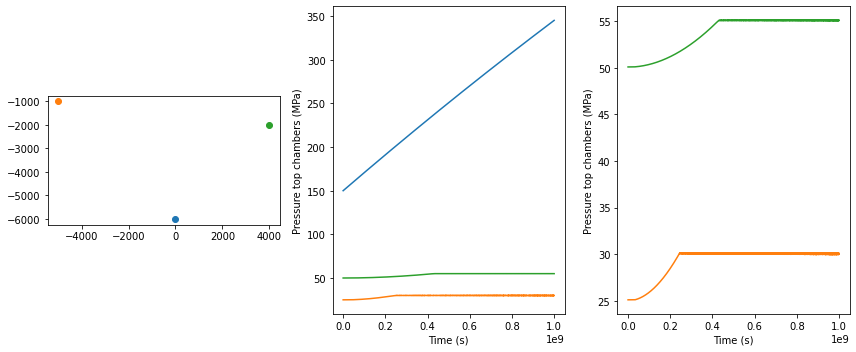

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,3,1)
color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
N_chambers = len(x_nodes)
for i in range(N_chambers):
  plt.scatter(x_nodes[i], z_nodes[i], c=color_cycle[i])
plt.gca().set_aspect('equal')

# plt.subplot(1,3,2)
# for i in range(3):
#   plt.plot(t_vec[:plot_idx], m[:,i][:plot_idx] - m[:,i][0])
# plt.xlabel("Time (s)")
# plt.ylabel("$\Delta m$ (kg)")

plot_idx = 200000

plt.subplot(1,3,2)
# plt.subplot(1,3,3)
for i in range(3):
  plt.plot(t_vec[:plot_idx], p[:,i][:plot_idx] / 1e6, color=color_cycle[i])
plt.xlabel("Time (s)")
plt.ylabel("Pressure top chambers (MPa)")
plt.tight_layout()

# plt.subplot(1,3,3)
plt.subplot(1,3,3)
for i in range(1,3):
  plt.plot(t_vec[:plot_idx], p[:,i][:plot_idx] / 1e6, color=color_cycle[i])
plt.xlabel("Time (s)")
plt.ylabel("Pressure top chambers (MPa)")
plt.tight_layout()

In [21]:
m_eruption_by_chamber = np.array([
  -f_erupt(t_vec[i], q_out[i,:])[global_sys.mass_indices]
  for i, t in enumerate(t_vec)])

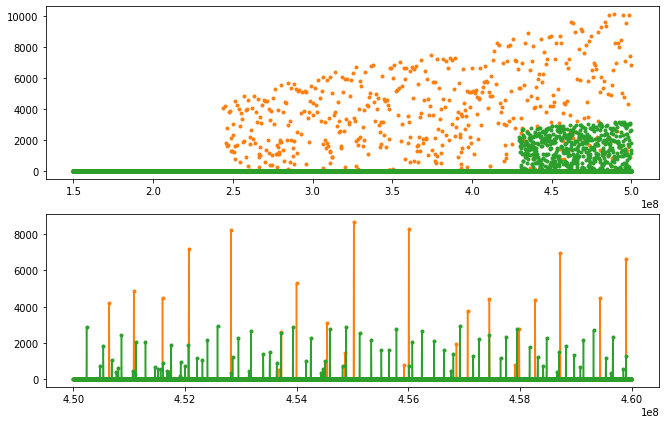

In [27]:
i1=30000
i2=100000
plt.figure(figsize=(11,7))
plt.subplot(2,1,1)
plt.plot(t_vec[i1:i2], m_eruption_by_chamber[i1:i2], '.')

i1=90000
i2=92000
plt.subplot(2,1,2)
plt.plot(t_vec[i1:i2], m_eruption_by_chamber[i1:i2], '.-')


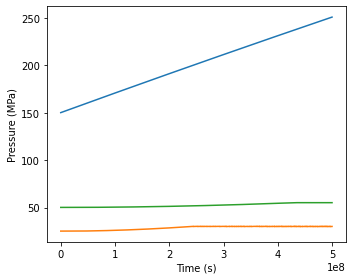

In [8]:
plt.figure(figsize=(5,4))

for i in range(3):
  plt.plot(t_vec[:plot_idx], p[:,i][:plot_idx] / 1e6, color=color_cycle[i])
plt.xlabel("Time (s)")
plt.ylabel("Pressure (MPa)")
plt.tight_layout()

Text(0, 0.5, 'Time of occurence (s)')

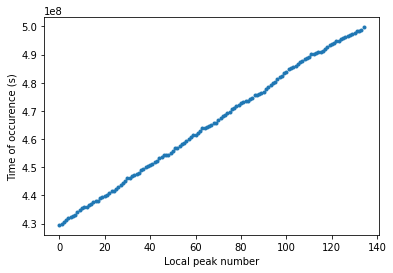

In [9]:
''' Peak picking '''
# Take data series
series = p[:,2][:plot_idx] / 1e6

# Compute boolean values corresponding to sign changes
is_peak = (np.diff(series[1:]) > 0).astype(float) * (np.diff(series[:-1]) < 0).astype(float)
# First time data is over 99% of the max
first_index = np.argmax(series > 0.99 * series.max())
# Compute indices where peak is detected in data series
peak_indices = (first_index + 1 + np.where(is_peak[first_index:])).squeeze()
plt.plot(t_vec[peak_indices], '.')
plt.xlabel("Local peak number")
plt.ylabel("Time of occurence (s)")